# Lab 10: Feature Selection

**Advanced Machine Learning — Google Colab**

### Lab target
Predict `LPA` using the five numerical candidate features defined for this Lab 10 version:

- `Age`
- `Study_Hours`
- `Attendance`
- `Assignments`
- `Exam_Score`

> **Important:** Duplicate handling and feature engineering are not performed in this lab. They were completed in earlier labs, so this notebook starts from the final clean student dataset and focuses on the later Lecture 10 topics.

## Learning Objectives

By the end of this lab, you will be able to:

1. Explain why feature selection can improve generalisation, efficiency, and interpretability.
2. Explain the bias–variance motivation and the curse of dimensionality.
3. Apply predefined filter functions for:
   - variance threshold,
   - Pearson target correlation,
   - input–input correlation screening.
4. Understand exhaustive feature search and why its cost grows exponentially without manually implementing it.
5. Use `SequentialFeatureSelector` for:
   - forward selection,
   - backward elimination.
6. Use cross-validation rather than training R² to compare feature-selection choices.
7. Use `Pipeline` so selection and model fitting are handled as one reproducible workflow, and use `RFECV` when the feature count should be selected by cross-validation.
8. Prevent feature-selection leakage and protect the final test set.
9. Report selected features as conditional on the target, model, metric, sample, and validation design.

## Dataset Description

This lab uses the final student CSV supplied for the project.

The dataset contains student information and the target `LPA`. For consistency with the established Lab 10 experiment, the feature-selection demonstrations use five numerical candidate predictors:

| Feature | Role |
|---|---|
| `Age` | Candidate predictor |
| `Study_Hours` | Candidate predictor |
| `Attendance` | Candidate predictor |
| `Assignments` | Candidate predictor |
| `Exam_Score` | Candidate predictor |
| `Year` | Candidate predictor |
| `LPA` | Regression target |

Other columns are not used in this numerical regression feature-selection experiment.

- `Student_ID` is an identifier, not a genuine predictive input.
- `Result` and `Grade` are derived from exam performance and require leakage awareness.
- `Placement` is derived from `LPA`, so using it to predict `LPA` would directly leak target information.
- `Entrance_Exam_Score` and `Rank` are present in the final CSV but are intentionally outside the established five-feature Lab 10 candidate set.

The worksheet stresses that a selected feature set is **conditional** on the target, model, metric, sample, and validation design.

## Part 0 — Colab Setup

Upload the CSV when running this notebook in Google Colab. The fallback path below is useful in the prepared execution environment.

In [1]:
import os
import glob
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("student_clean_dataset_2024.csv")


print("Shape:", df.shape)


Shape: (600, 17)


## Part 1 — Dataset Exploration

**Objective:** Understand the final dataset before applying selection methods.

In [2]:
print("First five rows:")
display(df.head())

print("\nData types:")
print(df.dtypes)

print("\nSummary statistics:")
display(df.describe())

print("\nMissing values:")
print(df.isnull().sum())

print("\nExact duplicate rows in the final dataset:", df.duplicated().sum())

First five rows:


,Student_ID,Name,Age,Gender,Prayers_Before_Exams,Department,Study_Hours,Attendance,Assignments,Exam_Score,Result,Grade,Entrance_Exam_Score,Rank,Placement,LPA,Year
0,ST001,Rina Bhat,17,Female,Yes,Information Technology,7,75,14,62.38,Pass,B,186,316,Placed,5.21,2024
1,ST002,Aika Sethi,19,Male,No,Electronics,5,99,11,63.49,Pass,B,190,289,Placed,5.87,2024
2,ST003,Takeru Khan,19,Female,No,Computer Science,7,89,14,65.81,Pass,B,196,263,Placed,4.47,2024
3,ST004,Marina Bansal,19,Male,No,Electronics,0,83,3,17.27,Fail,F,57,593,Not Placed,0.00,2024
4,ST005,Honoka Patil,19,Male,No,Mechanical,8,80,20,95.79,Pass,A+,294,7,Placed,9.34,2024



Data types:
Student_ID                  str
Name                        str
Age                       int64
Gender                      str
Prayers_Before_Exams        str
Department                  str
Study_Hours               int64
Attendance                int64
Assignments               int64
Exam_Score              float64
Result                      str
Grade                       str
Entrance_Exam_Score       int64
Rank                      int64
Placement                   str
LPA                     float64
Year                      int64
dtype: object

Summary statistics:


,Age,Study_Hours,Attendance,Assignments,Exam_Score,Entrance_Exam_Score,Rank,LPA,Year
count,600.000000,600.000000,600.000000,600.000000,600.000000,600.000000,600.000000,600.000000,600.0
mean,18.420000,5.173333,81.401667,13.161667,62.087783,186.473333,300.500000,3.122733,2024.0
std,0.870745,2.063262,9.422932,3.732571,17.191859,51.963509,173.349358,3.758607,0.0
min,17.000000,0.000000,60.000000,1.000000,8.290000,27.000000,1.000000,0.000000,2024.0
25%,18.000000,4.000000,74.000000,11.000000,52.417500,156.750000,150.750000,0.000000,2024.0
50%,18.000000,5.000000,81.000000,13.000000,62.650000,189.000000,300.500000,0.000000,2024.0
75%,19.000000,7.000000,89.000000,16.000000,74.092500,221.250000,450.250000,5.790000,2024.0
max,20.000000,10.000000,100.000000,20.000000,100.000000,300.000000,600.000000,21.000000,2024.0



Missing values:
Student_ID              0
Name                    0
Age                     0
Gender                  0
Prayers_Before_Exams    0
Department              0
Study_Hours             0
Attendance              0
Assignments             0
Exam_Score              0
Result                  0
Grade                   0
Entrance_Exam_Score     0
Rank                    0
Placement               0
LPA                     0
Year                    0
dtype: int64

Exact duplicate rows in the final dataset: 0


### Interpretation

This notebook does **not** create duplicate rows, duplicate columns, or engineered variables.

The duplicate count is shown only as a diagnostic check confirming the condition of the final dataset supplied for this lab.

## Part 2 — Feature Selection Foundations

### Relevant, redundant, and irrelevant

- **Relevant:** carries stable information that helps predict the target.
- **Redundant:** repeats information already carried by another input.
- **Irrelevant:** varies but does not provide stable predictive information for the target.

### Feature selection vs. feature transformation

**Feature selection** retains a subset of existing columns.

**Feature transformation** creates a new representation or new features.

Students have already covered feature engineering in earlier labs, so this Lab 10 notebook focuses on selecting among existing candidate inputs.

## Part 3 — Why Feature Selection?

### 3.1 Bias–variance connection

Adding useful features can reduce bias because the model has more information available. Adding irrelevant or noisy features can increase variance and hurt performance on unseen data.

The important comparison is therefore:

**training performance vs. validation/generalisation performance**

—not simply whether training R² increases.

### 3.2 Curse of dimensionality

As the number of features increases, the possible combinations and the size of the feature space grow rapidly.

For `p` candidate features, exhaustive search has:

\[
2^p - 1
\]

non-empty subsets.

For example:

- 5 features → 31 subsets
- 20 features → 1,048,575 subsets
- 30 features → 1,073,741,823 subsets

This is why practical systems often use filters and sequential wrapper methods rather than exhaustive search for large feature spaces.

In [3]:
for p in [5, 20, 30]:
    print(f"{p} features -> {2**p - 1:,} non-empty subsets")

5 features -> 31 non-empty subsets
20 features -> 1,048,575 non-empty subsets
30 features -> 1,073,741,823 non-empty subsets


### Controlled bias–variance demonstration

To make the generalisation idea visible without changing the real feature-selection dataset, we add controlled random noise **only to this demonstration**. These variables are not used anywhere in the actual feature-selection workflow.

In [4]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import KFold, cross_val_score

RANDOM_STATE = 42
candidate_features = ["Age", "Study_Hours", "Attendance", "Assignments", "Exam_Score","Year"]
TARGET = "LPA"

X_base = df[candidate_features].copy()
y = df[TARGET].copy()

rng = np.random.default_rng(RANDOM_STATE)
cv = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

noise_counts = [0, 10, 20, 50]
demo_rows = []

for n_noise in noise_counts:
    # =========================================================================
    # TODO: Complete the bias-variance demonstration loop
    # =========================================================================
    # Step 1: Make a copy of X_base and store it in X_demo
    X_demo = X_base.copy()
    if n_noise:
        noise = rng.normal(size=(len(X_demo), n_noise))
        for j in range(n_noise):
            X_demo[f"Noise_{j+1}"] = noise[:, j]
            
    # Step 3: Create a LinearRegression() model
    model = LinearRegression()
    
    # Step 4: Fit the model on X_demo and y
    #         - Use model.fit(X_demo, y)
    model.fit(X_demo, y)
    
    # Step 5: Compute training R² using model.score(X_demo, y)
    #         - Store in variable 'train_r2'
    train_r2 = model.score(X_demo, y)
    
    # Step 6: Compute 5-fold cross-validated R² using:
    #         cross_val_score(model, X_demo, y, cv=cv, scoring="r2").mean()
    #         - Store in variable 'cv_r2'
    cv_r2 = cross_val_score(model, X_demo, y, cv=cv, scoring="r2").mean()
    
    # Step 7: Append a dict to demo_rows with keys:
    #         "Noise features", "Total features", "Training R²", "5-fold CV R²"
    demo_rows.append({
        "Noise features": n_noise,
        "Total features": X_demo.shape[1],
        "Training R²": train_r2,
        "5-fold CV R²": cv_r2
    })

demo_results = pd.DataFrame(demo_rows)
display(demo_results.round(3))


,Noise features,Total features,Training R²,5-fold CV R²
0,0,6,0.496,0.480
1,10,16,0.502,0.468
2,20,26,0.511,0.437
3,50,56,0.535,0.405


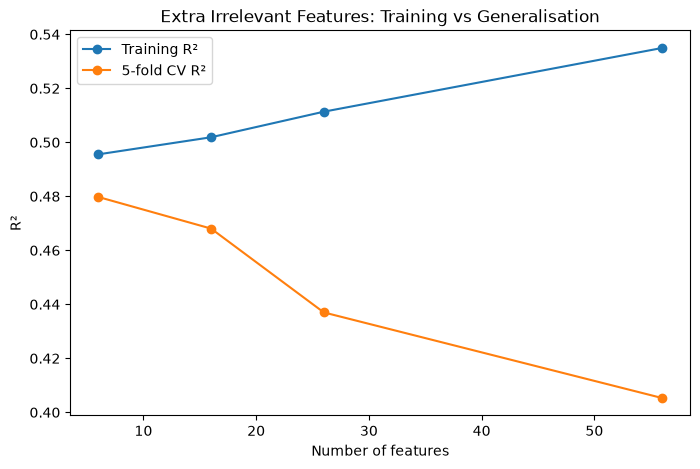

In [5]:
plt.figure(figsize=(8, 5))
plt.plot(demo_results["Total features"], demo_results["Training R²"], marker="o", label="Training R²")
plt.plot(demo_results["Total features"], demo_results["5-fold CV R²"], marker="o", label="5-fold CV R²")
plt.xlabel("Number of features")
plt.ylabel("R²")
plt.title("Extra Irrelevant Features: Training vs Generalisation")
plt.legend()
plt.show()

**Observation:** training R² can remain flat or increase as irrelevant features are added, while cross-validated R² can decline. This is the reason feature selection should be evaluated using generalisation performance.

---

# Part 4 — Filter Methods

Filter methods screen features using structural or statistical criteria rather than repeatedly training the final model on every candidate subset.

In this lab, we use predefined functions rather than implementing the filtering algorithms ourselves.

## 4.1 Variance Threshold

`VarianceThreshold` is a predefined scikit-learn transformer.

It is **target-independent**: it checks how much a feature varies, not how predictive it is.

A zero-variance feature is constant and cannot distinguish observations.

> A high-variance feature is not automatically useful, and a low-variance feature is not automatically useless.

In [6]:
from sklearn.feature_selection import VarianceThreshold

X = df[candidate_features].copy()

# =============================================================================
# TODO: Apply VarianceThreshold to remove zero-variance features
# =============================================================================
# Step 1: Create a VarianceThreshold object
#         - Parameter: threshold=0.0 (removes only constant/zero-variance features)
#         - Store in variable 'variance_filter'

variance_filter = VarianceThreshold(threshold=0.0)

# Step 2: Apply fit_transform on X
#         - Call variance_filter.fit_transform(X)
#         - Store the result in 'X_variance'

X_variance = variance_filter.fit_transform(X)

# Step 3: Get the names of retained features
#         - Use X.columns[variance_filter.get_support()].tolist()
#         - get_support() returns a boolean mask of which features passed the filter
#         - Store the result in 'variance_features'

variance_features = X.columns[variance_filter.get_support()].tolist()

print("Features before variance filtering:", X.columns.tolist())
print("Features after VarianceThreshold:", variance_features)


Features before variance filtering: ['Age', 'Study_Hours', 'Attendance', 'Assignments', 'Exam_Score', 'Year']
Features after VarianceThreshold: ['Age', 'Study_Hours', 'Attendance', 'Assignments', 'Exam_Score']


### Why use the predefined transformer?

The student does not need to calculate variances, construct masks, or write a feature-dropping loop manually.

The library object handles:

1. fitting the threshold,
2. storing the selected feature mask,
3. transforming the matrix,
4. exposing the retained columns through `get_support()`.

## 4.2 Pearson Correlation with the Target

Pearson correlation measures **linear association**.

- `r` near +1 → strong positive linear association
- `r` near −1 → strong negative linear association
- `r` near 0 → weak linear association

A classroom threshold such as `|r| >= 0.30` is only illustrative. It is not a universal production rule.

In [7]:

target_corr =  df[candidate_features + [TARGET]].corr(numeric_only=True)[TARGET].drop(TARGET)
target_corr = target_corr.sort_values(key=lambda s: s.abs(), ascending=False)
display(target_corr.rename("Pearson r with LPA").to_frame())


,Pearson r with LPA
Exam_Score,0.702548
Assignments,0.674684
Study_Hours,0.619016
Attendance,0.080865
Age,-0.039675
Year,NaN


### Pearson's important limitation

Pearson correlation can miss nonlinear relationships.

For a symmetric set of `x` values with `y = x²`, Pearson correlation can be approximately zero even though `y` is completely determined by `x`.

Therefore:

> **Zero Pearson correlation does not prove that a feature has zero predictive value.**

This is why correlation should be treated as a screening tool, not as a universal definition of feature importance.

## 4.3 Input–Input Correlation

Correlation can also be used between predictors to identify redundancy and potential multicollinearity.

A common classroom rule is to flag pairs with very high absolute correlation, for example `|r| >= 0.85`.

This is a **screening signal**, not an automatic command to delete a feature. The final decision should consider validation performance, measurement quality, interpretability, and domain context.

,Age,Study_Hours,Attendance,Assignments,Exam_Score,Year
Age,1.000,-0.020,-0.011,-0.031,-0.021,NaN
Study_Hours,-0.020,1.000,0.016,0.847,0.880,NaN
Attendance,-0.011,0.016,1.000,-0.001,0.146,NaN
Assignments,-0.031,0.847,-0.001,1.000,0.964,NaN
Exam_Score,-0.021,0.880,0.146,0.964,1.000,NaN
Year,NaN,NaN,NaN,NaN,NaN,NaN


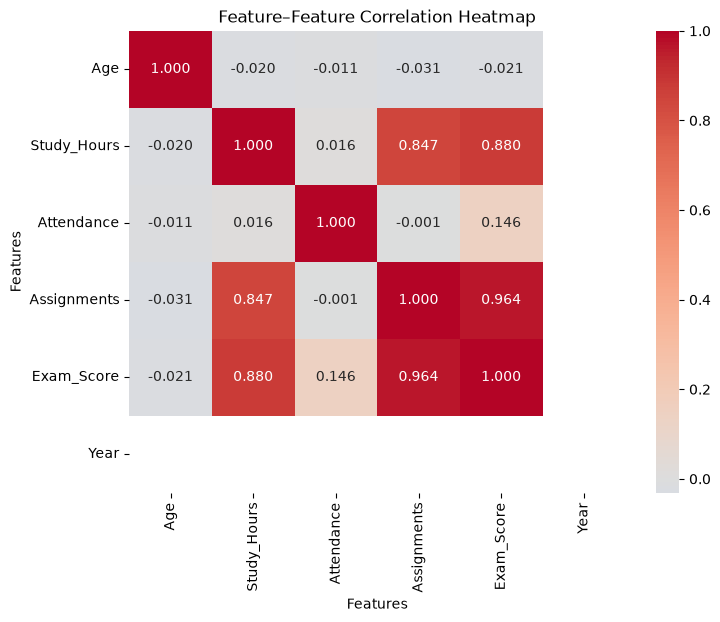

,Feature 1,Feature 2,Pearson r
0,Study_Hours,Exam_Score,0.880401
1,Assignments,Exam_Score,0.964446


In [8]:
# =============================================================================
# TODO: Compute input-input (feature-feature) correlation matrix
#       and identify highly correlated pairs
# =============================================================================
# Step 1: Compute the correlation matrix of features
#         - Use X.corr()
#         - Store in 'feature_corr'

feature_corr = X.corr()
display(feature_corr.round(3))

# Step 2: Display the correlation matrix as a heatmap
plt.figure(figsize=(8, 6))

sns.heatmap(
    feature_corr,
    annot=True,
    fmt=".3f",
    cmap="coolwarm",
    center=0
)

plt.title("Feature–Feature Correlation Heatmap")
plt.xlabel("Features")
plt.ylabel("Features")
plt.show()

# Step 3: Set a threshold for high correlation
threshold = 0.85
high_corr_pairs = []

# Step 4: Find all feature pairs with |r| >= threshold
for i in range(len(feature_corr.columns)):
    for j in range(i + 1, len(feature_corr.columns)):
        r = feature_corr.iloc[i, j]

        if abs(r) >= threshold:
            high_corr_pairs.append({
                "Feature 1": feature_corr.columns[i],
                "Feature 2": feature_corr.columns[j],
                "Pearson r": r
            })

high_corr_pairs = pd.DataFrame(high_corr_pairs)

# Step 5: Display results
if high_corr_pairs.empty:
    print(f"No feature pair has |r| >= {threshold}.")
else:
    display(high_corr_pairs)


# Part 5 — Wrapper Methods Using Predefined Functions

Wrapper methods evaluate subsets using the predictive model and a validation score.

The lecture covers:

1. Exhaustive search
2. Backward elimination
3. Sequential forward selection

### Implementation policy for this lab

- **No manual subset-search loops.**
- **No manually coded forward-selection algorithm.**
- **No manually coded backward-elimination algorithm.**
- Use established library functionality.
- For sequential wrapper selection, use scikit-learn's `SequentialFeatureSelector`.
- Exhaustive search is explained conceptually because scikit-learn does not provide a native exhaustive subset selector in `sklearn.feature_selection`. We do not reimplement it manually in this lab.

## 5.1 Exhaustive Search — Concept, Not a Hand-Coded Algorithm

Exhaustive search evaluates every non-empty subset:

\[
2^p - 1
\]

For the five candidate features in this lab:

\[
2^5 - 1 = 31
\]

That is feasible for a tiny demonstration, but the cost grows exponentially.

**Industry practice:** when exhaustive search is genuinely required, use a maintained, tested library implementation rather than writing the search loop yourself. For larger feature spaces, sequential wrapper methods are usually much more practical.

The important skill here is knowing what exhaustive search means, understanding its computational cost, and knowing when not to use it.

In [9]:
p = len(candidate_features)
print(f"Candidate features (p): {p}")
print(f"Non-empty exhaustive subsets: {2**p - 1}")
print("Growth is exponential: 2^p - 1")

Candidate features (p): 6
Non-empty exhaustive subsets: 63
Growth is exponential: 2^p - 1


## 5.2 Forward Selection with `SequentialFeatureSelector`

`SequentialFeatureSelector` is the predefined scikit-learn implementation.

Forward selection starts with no selected features and adds features sequentially according to cross-validated model performance.

In [10]:
from sklearn.feature_selection import SequentialFeatureSelector

linear_model = LinearRegression()

# =============================================================================
# TODO: Perform forward feature selection using SequentialFeatureSelector
# =============================================================================
# Step 1: Create a SequentialFeatureSelector for FORWARD selection
#         - Parameters:
#             estimator=linear_model     (the model to evaluate features with)
#             n_features_to_select=3     (how many features to keep)
#             direction="forward"        (start empty, add features one by one)
#             scoring="r2"               (evaluation metric)
#             cv=5                       (5-fold cross-validation)
#         - Store in 'sfs_forward'
#
# Step 2: Fit the selector on X and y
#         - sfs_forward.fit(X, y)

sfs_forward = SequentialFeatureSelector(
    estimator=linear_model,
    n_features_to_select=3,
    direction="forward",
    scoring="r2",
    cv=5
)

sfs_forward.fit(X, y)

forward_features = X.columns[sfs_forward.get_support()].tolist()

print("Forward-selected features:")
print(forward_features)


Forward-selected features:
['Assignments', 'Exam_Score', 'Year']


### What the library is doing

Conceptually, the selector performs the forward-search process for us:

- start with an empty subset,
- evaluate candidate additions using cross-validation,
- choose the next feature,
- continue until the requested number of features is reached.

We do **not** write this loop ourselves.

## 5.3 Backward Elimination with `SequentialFeatureSelector`

Backward selection starts from the full candidate set and removes features sequentially according to cross-validated model performance.

In [11]:
# =============================================================================
# TODO: Perform backward feature elimination using SequentialFeatureSelector
# =============================================================================
# Step 1: Create a SequentialFeatureSelector for BACKWARD elimination
#         - Parameters (same as forward, EXCEPT direction):
#             estimator=linear_model
#             n_features_to_select=3
#             direction="backward"       (start with ALL features, remove one by one)
#             scoring="r2"
#             cv=5
#         - Store in 'sfs_backward'
#
# Step 2: Fit the selector on X and y
#
# Step 3: Extract selected feature names
#         - Store in 'backward_features'
# =============================================================================

sfs_backward = SequentialFeatureSelector(
    estimator=linear_model,
    n_features_to_select=3,
    direction="backward",
    scoring="r2",
    cv=5
)

sfs_backward.fit(X, y)

backward_features = X.columns[sfs_backward.get_support()].tolist()

print("Backward-selected features:")
print(backward_features)


Backward-selected features:


['Assignments', 'Exam_Score', 'Year']


### Forward vs. backward

| Method | Starting point | Direction |
|---|---|---|
| Forward | No features | Add features |
| Backward | All candidate features | Remove features |

Both are **greedy** sequential searches. They are much cheaper than exhaustive search, but they can miss a globally best subset.

The selected subset is also model-specific because the wrapper evaluates the chosen estimator and metric.

# Part 6 — Validation Discipline and Data Leakage

Feature selection is part of the learning process.

### Incorrect

```text
Full dataset
    ↓
Select features
    ↓
Split into train/test
```

The selection step has already seen the future test observations.

### Correct

```text
Full dataset
    ↓
Train/Test split
    ↓
Selection + model fitting inside training/CV
    ↓
Final test evaluation once
```

When a target-informed selector is evaluated with cross-validation, the selector must be fitted separately inside each training fold. A `Pipeline` is the standard way to enforce this structure.

## 6.1 Demonstrating the correct pattern with `Pipeline`

The pipeline below combines predefined components:

1. `VarianceThreshold`
2. `SequentialFeatureSelector`
3. `LinearRegression`

There is no custom selection algorithm.

In [12]:
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split, cross_val_score, KFold

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=RANDOM_STATE
)

# TODO: Initialize cv using KFold with 5 splits and shuffling enabled.
#       Set random_state to RANDOM_STATE for reproducibility.
cv = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

# =============================================================================
# TODO: Build a Pipeline for forward selection + linear regression
# =============================================================================
# A Pipeline chains multiple steps so that feature selection and model fitting
# happen together. This prevents data leakage: the selector is fitted only on
# training folds, never seeing test data.
#
# Step 1: Create a Pipeline with 3 named steps:
#         - ("variance", VarianceThreshold(threshold=0.0))
#              → removes zero-variance features
#         - ("selector", SequentialFeatureSelector(
#              LinearRegression(),
#              n_features_to_select=3,
#              direction="forward",
#              scoring="r2",
#              cv=5
#           ))  → selects 3 best features using forward selection
#         - ("model", LinearRegression())
#              → the final estimator
#         - Store in 'pipeline_forward'
#
# Step 2: Evaluate using cross_val_score
#         - cross_val_score(pipeline_forward, X_train, y_train, cv=cv, scoring="r2")
#         - Store in 'cv_scores_forward'
#
# Step 3: Fit the pipeline on training data
#         - pipeline_forward.fit(X_train, y_train)
# =============================================================================

pipeline_forward = Pipeline([
    ("variance", VarianceThreshold(threshold=0.0)),
    ("selector", SequentialFeatureSelector(
        LinearRegression(),
        n_features_to_select=3,
        direction="forward",
        scoring="r2",
        cv=5
    )),
    ("model", LinearRegression())
])

cv_scores_forward = cross_val_score(
    pipeline_forward,
    X_train,
    y_train,
    cv=cv,
    scoring="r2"
)

pipeline_forward.fit(X_train, y_train)  # Fit pipeline_forward on X_train, y_train

print("Forward pipeline CV R² scores:", np.round(cv_scores_forward, 3))
print("Mean CV R²:", round(cv_scores_forward.mean(), 3))


Forward pipeline CV R² scores: [0.456 0.362 0.509 0.449 0.537]
Mean CV R²: 0.463


## 6.2 Backward Elemination Inside a Pipeline

The same predefined pipeline structure can use the backward direction.

In [13]:
# =============================================================================
# TODO: Build a Pipeline for backward elimination + linear regression
# =============================================================================
# Same structure as the forward pipeline, but change direction to "backward"
#
# Step 1: Create a Pipeline with 3 named steps:
#         - ("variance", VarianceThreshold(threshold=0.0))
#         - ("selector", SequentialFeatureSelector(
#              LinearRegression(),
#              n_features_to_select=3,
#              direction="backward",     ← THIS IS THE KEY DIFFERENCE
#              scoring="r2",
#              cv=5
#           ))
#         - ("model", LinearRegression())
#         - Store in 'pipeline_backward'
#
# Step 2: Evaluate using cross_val_score on X_train, y_train
#         - Store in 'cv_scores_backward'
#
# Step 3: Fit the pipeline on training data
# =============================================================================

pipeline_backward = Pipeline([
    ("variance", VarianceThreshold(threshold=0.0)),
    ("selector", SequentialFeatureSelector(
        LinearRegression(),
        n_features_to_select=3,
        direction="backward",
        scoring="r2",
        cv=5
    )),
    ("model", LinearRegression())
])

cv_scores_backward = cross_val_score(
    pipeline_backward,
    X_train,
    y_train,
    cv=cv,
    scoring="r2"
)

pipeline_backward.fit(X_train, y_train)

print("Backward pipeline CV R² scores:", np.round(cv_scores_backward, 3))
print("Mean CV R²:", round(cv_scores_backward.mean(), 3))


Backward pipeline CV R² scores: [0.456 0.362 0.509 0.449 0.536]
Mean CV R²: 0.462


# Part 7 — Recursive Feature Elimination (RFE)

`RFE` is a predefined scikit-learn wrapper method. It repeatedly fits the estimator and removes the least important features according to the estimator's coefficients or feature importances.

For `LinearRegression`, RFE uses the magnitude of the fitted coefficients to determine which features to eliminate.

Unlike Sequential Feature Selection, RFE works by **recursive elimination** from the full candidate set.

We specify the desired number of features with `n_features_to_select`.

In [14]:
from sklearn.feature_selection import RFE
from sklearn.linear_model import LinearRegression

# Use only the training data for feature-selection decisions.
X_train_rfe = X_train[candidate_features]

# =============================================================================
# TODO: Apply Recursive Feature Elimination (RFE)
# =============================================================================
# RFE repeatedly fits the model and removes the LEAST important feature
# (based on coefficient magnitudes for LinearRegression) until the desired
# number of features remains.
#
# Step 1: Create an RFE object
#         - Parameters:
#             estimator=LinearRegression()  (the model used to rank features)
#             n_features_to_select=3         (how many features to keep)
#             step=1                         (remove 1 feature per iteration)
#         - Store in 'rfe'
#
# Step 2: Fit RFE on training data only
#         - rfe.fit(X_train_rfe, y_train)
#
# Step 3: Get the selected features
#         - Use X_train_rfe.columns[rfe.support_].tolist()
#         - rfe.support_ is a boolean array: True for selected features
#         - Store in 'rfe_features'
#
# Step 4: Create a ranking Series
#         - Use pd.Series(rfe.ranking_, index=X_train_rfe.columns).sort_values()
#         - rfe.ranking_ assigns rank 1 to selected features, 2+ to eliminated ones
#         - Store in 'rfe_ranking'
# =============================================================================

X_train_rfe = X_train[candidate_features]

rfe = RFE(
    estimator=LinearRegression(),
    n_features_to_select=3,
    step=1
)

rfe.fit(X_train_rfe, y_train)

rfe_features = X_train_rfe.columns[rfe.support_].tolist()

print("Selected features by RFE:")
print(rfe_features)

print("\nFeature ranking:")
rfe_ranking = pd.Series(
    rfe.ranking_,
    index=X_train_rfe.columns
).sort_values()

display(rfe_ranking.to_frame("RFE_Ranking"))


Selected features by RFE:
['Age', 'Assignments', 'Exam_Score']

Feature ranking:


,RFE_Ranking
Age,1
Assignments,1
Exam_Score,1
Study_Hours,2
Attendance,3
Year,4


# Part 8 — Recursive Feature Elimination with Cross-Validation (RFECV)

`RFECV` extends RFE by using cross-validation to determine how many features should be retained.

Instead of fixing `n_features_to_select`, RFECV evaluates different feature counts and selects the count associated with the best cross-validated performance.

This makes RFECV useful when the appropriate feature count is not known in advance.

The selected feature count is still conditional on the estimator, scoring metric, candidate features, sample, and cross-validation design.

In [15]:
from sklearn.feature_selection import RFECV

# =============================================================================
# TODO: Apply Recursive Feature Elimination with Cross-Validation (RFECV)
# =============================================================================
# RFECV extends RFE by using cross-validation to automatically determine
# the OPTIMAL number of features. You don't need to specify
# n_features_to_select — RFECV finds it for you!
#
# Step 1: Create an RFECV object
#         - Parameters:
#             estimator=LinearRegression()   (model used for ranking)
#             step=1                          (remove 1 feature per iteration)
#             cv=cv                           (cross-validation strategy, defined earlier)
#             scoring="r2"                    (metric to evaluate)
#             min_features_to_select=1        (minimum features to try)
#         - Store in 'rfecv'
#
# Step 2: Fit RFECV on training data only
#         - rfecv.fit(X_train[candidate_features], y_train)
#
# Step 3: Get selected features
#         - Use X_train[candidate_features].columns[rfecv.support_].tolist()
#         - Store in 'rfecv_features'
#
# Step 4: Print the optimal number of features
#         - rfecv.n_features_ gives the optimal count chosen by CV
#
# Step 5: Create a ranking Series (same approach as RFE)
#         - pd.Series(rfecv.ranking_, index=X_train[candidate_features].columns).sort_values()
#         - Store in 'rfecv_ranking'
# =============================================================================

rfecv = RFECV(
    estimator=LinearRegression(),
    step=1,
    cv=cv,
    scoring="r2",
    min_features_to_select=1
)

rfecv.fit(X_train[candidate_features], y_train)

rfecv_features = X_train[candidate_features].columns[rfecv.support_].tolist()

print("Selected features by RFECV:")
print(rfecv_features)

print("\nOptimal number of features:")
print(rfecv.n_features_)

print("\nFeature ranking:")
rfecv_ranking = pd.Series(
    rfecv.ranking_,
    index=X_train[candidate_features].columns
).sort_values()

display(rfecv_ranking.to_frame("RFECV_Ranking"))


Selected features by RFECV:
['Assignments', 'Exam_Score']

Optimal number of features:
2

Feature ranking:


,RFECV_Ranking
Assignments,1
Exam_Score,1
Age,2
Study_Hours,3
Attendance,4
Year,5


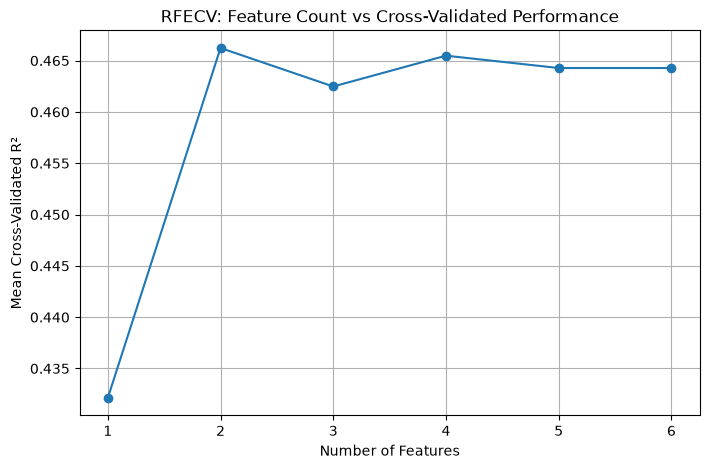

In [16]:
cv_results = rfecv.cv_results_

# Older scikit-learn versions may not provide cv_results_["n_features"].
# RFECV evaluates feature subsets from min_features_to_select up to p.
if "n_features" in cv_results:
    n_features = cv_results["n_features"]
else:
    n_features = np.arange(
        rfecv.min_features_to_select,
        rfecv.n_features_in_ + 1
    )

mean_scores = cv_results["mean_test_score"]

plt.figure(figsize=(8, 5))
plt.plot(n_features, mean_scores, marker="o")
plt.xlabel("Number of Features")
plt.ylabel("Mean Cross-Validated R²")
plt.title("RFECV: Feature Count vs Cross-Validated Performance")
plt.grid(True)
plt.show()


## 8.1 RFECV Inside a Pipeline

The safest reusable pattern is to keep feature selection and model fitting inside the same predefined `Pipeline`.

The pipeline below contains:

1. `VarianceThreshold`
2. `RFECV`
3. `LinearRegression`

When the pipeline is evaluated with cross-validation, the feature-selection step is fitted separately within each training fold. This helps prevent feature-selection leakage.

In [17]:
# =============================================================================
# TODO: Build a Pipeline with RFECV for automatic feature count selection
# =============================================================================
# This pipeline combines:
#   1. VarianceThreshold — removes zero-variance features
#   2. RFECV — recursively eliminates features using CV to find optimal count
#   3. LinearRegression — the final model
#
# Step 1: Create a Pipeline with 3 named steps:
#         - ("variance", VarianceThreshold(threshold=0.0))
#         - ("selector", RFECV(
#              estimator=LinearRegression(),
#              step=1,
#              cv=5,
#              scoring="r2",
#              min_features_to_select=1
#           ))
#         - ("model", LinearRegression())
#         - Store in 'pipeline_rfecv'
#
# Step 2: Evaluate using cross_val_score
#         - cross_val_score(pipeline_rfecv, X_train[candidate_features],
#                           y_train, cv=cv, scoring="r2")
#         - Store in 'cv_scores_rfecv'
#
# Step 3: Fit the pipeline on training data
#         - pipeline_rfecv.fit(X_train[candidate_features], y_train)
# =============================================================================

pipeline_rfecv = Pipeline([
    ("variance", VarianceThreshold(threshold=0.0)),
    ("selector", RFECV(
        estimator=LinearRegression(),
        step=1,
        cv=5,
        scoring="r2",
        min_features_to_select=1
    )),
    ("model", LinearRegression())
])

cv_scores_rfecv = cross_val_score(
    pipeline_rfecv,
    X_train[candidate_features],
    y_train,
    cv=cv,
    scoring="r2"
)

pipeline_rfecv.fit(X_train[candidate_features], y_train)

print("RFECV pipeline CV R² scores:", np.round(cv_scores_rfecv, 3))
print("Mean CV R²:", round(cv_scores_rfecv.mean(), 3))

# RFECV is applied after VarianceThreshold, so map the selector mask
# back to the feature names that actually reach the selector.
variance_step = pipeline_rfecv.named_steps["variance"]
selector_features = X_train[candidate_features].columns[
    variance_step.get_support()
].tolist()

rfecv_pipeline_selector = pipeline_rfecv.named_steps["selector"]
rfecv_pipeline_features = [
    feature
    for feature, selected in zip(
        selector_features,
        rfecv_pipeline_selector.support_
    )
    if selected
]

print("Selected features in fitted RFECV pipeline:")
print(rfecv_pipeline_features)
print("Selected feature count:", rfecv_pipeline_selector.n_features_)


RFECV pipeline CV R² scores: [0.464 0.366 0.499 0.449 0.537]
Mean CV R²: 0.463
Selected features in fitted RFECV pipeline:
['Age', 'Study_Hours', 'Assignments', 'Exam_Score']
Selected feature count: 4


# Part 9 — Baseline vs. Selected-Feature Pipeline

The final comparison uses the same cross-validation design for an all-feature baseline and the RFECV pipeline.

RFECV already uses cross-validation to determine the feature count.
- `Pipeline` keeps selection and modeling together.
- The untouched test set is used only after the selection workflow is fixed.

In [18]:
from sklearn.metrics import r2_score

baseline_pipeline = Pipeline([
    ("variance", VarianceThreshold(threshold=0.0)),
    ("model", LinearRegression())
])

baseline_cv_scores = cross_val_score(
    baseline_pipeline,
    X_train[candidate_features],
    y_train,
    cv=cv,
    scoring="r2"
)

baseline_pipeline.fit(X_train[candidate_features], y_train)

# Final test evaluation is performed only after the feature-selection strategy is fixed.
test_r2_baseline = r2_score(
    y_test,
    baseline_pipeline.predict(X_test[candidate_features])
)

test_r2_rfecv = r2_score(
    y_test,
    pipeline_rfecv.predict(X_test[candidate_features])
)

test_results = pd.DataFrame({
    "Model": [
        "All-feature baseline",
        "RFECV pipeline"
    ],
    "Mean CV R²": [
        baseline_cv_scores.mean(),
        cv_scores_rfecv.mean()
    ],
    "Test R²": [
        test_r2_baseline,
        test_r2_rfecv
    ]
})

display(test_results.round(3))

,Model,Mean CV R²,Test R²
0,All-feature baseline,0.464,0.518
1,RFECV pipeline,0.463,0.528


### Interpretation

Do not interpret a selected subset as universally "important."

The result is conditional on:

- this dataset/sample,
- target = `LPA`,
- estimator = `LinearRegression`,
- metric = `R²`,
- cross-validation design,
- candidate feature set,
- feature-selection method and configuration.

A different target, model, sample, metric, or validation design can produce a different subset.